# Model Validation, Overfitting Control & Hyperparameter Tuning

**Maincrafts Technology - Artificial Intelligence & Machine Learning Internship**  
**Task 3**

This notebook enhances the California Housing prediction workflow with overfitting analysis, 5-fold cross-validation, GridSearchCV hyperparameter tuning, optimized model comparison, saved artifacts, and clear model-selection justification.

## Objective

The objective is to move beyond a single train-test evaluation and apply professional validation techniques. The workflow detects overfitting in a Decision Tree Regressor, estimates generalization with cross-validation, tunes tree complexity with GridSearchCV, and selects the final model using RMSE and R2.

## Import Libraries

The project uses pandas and NumPy for data handling, scikit-learn for preprocessing, model validation, tuning, and evaluation, matplotlib for visualizations, and joblib for model persistence.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

BASE_DIR = Path.cwd()
PLOTS_DIR = BASE_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

## Dataset Loading

The official task uses the California Housing dataset through `fetch_california_housing(as_frame=True)`. The original target column `MedHouseVal` is renamed to `HousePrice` for readability and consistency with previous internship tasks.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy().rename(columns={"MedHouseVal": "HousePrice"})
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Inspection

Before modeling, the dataset is checked for shape, column names, data types, missing values, and descriptive statistics. This confirms that the data is ready for scaling and model training.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
df.describe().T

Dataset shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']

Data types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
HousePrice,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Feature Scaling

The same preprocessing approach used in Task 2 is applied here: the eight California Housing predictors are scaled with `StandardScaler`. Scaling keeps the baseline workflow consistent across the internship portfolio.

In [4]:
feature_names = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]
X = df[feature_names]
y = df["HousePrice"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=feature_names).head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## Train-Test Split

The scaled data is split into 80% training data and 20% testing data with `random_state=42`. The test set is held back for final model comparison after baseline training and tuning.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


## Baseline Models

The baseline stage trains the same three models used in Task 2: Linear Regression, Ridge Regression, and a Decision Tree Regressor with `max_depth=5`. This creates a fair before-and-after comparison for Task 3 optimization.

In [6]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Original Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
}

baseline_rows = []
fitted_models = {}
predictions_by_model = {}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    baseline_rows.append({
        "Model": name,
        "RMSE": rmse(y_test, predictions),
        "R2 Score": float(r2_score(y_test, predictions)),
        "Model Type": "Baseline",
    })
    fitted_models[name] = model
    predictions_by_model[name] = predictions

pd.DataFrame(baseline_rows)

,Model,RMSE,R2 Score,Model Type
0,Linear Regression,0.745581,0.575788,Baseline
1,Ridge Regression,0.745554,0.575819,Baseline
2,Original Decision Tree,0.724234,0.599732,Baseline


## Overfitting Analysis

Overfitting is detected by comparing training error and testing error. A model that performs much better on training data than unseen test data is likely memorizing training patterns instead of generalizing.

In [7]:
original_tree = fitted_models["Original Decision Tree"]
train_predictions = original_tree.predict(X_train)
test_predictions = predictions_by_model["Original Decision Tree"]

overfitting_analysis = {
    "Train RMSE": rmse(y_train, train_predictions),
    "Test RMSE": rmse(y_test, test_predictions),
}
overfitting_analysis["RMSE Gap"] = overfitting_analysis["Test RMSE"] - overfitting_analysis["Train RMSE"]
pd.Series(overfitting_analysis)

Train RMSE    0.695948
Test RMSE     0.724234
RMSE Gap      0.028286
dtype: float64

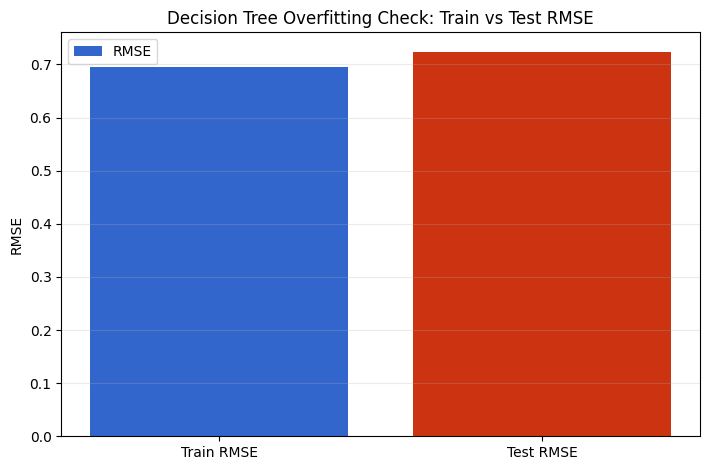

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.bar(["Train RMSE", "Test RMSE"], [overfitting_analysis["Train RMSE"], overfitting_analysis["Test RMSE"]],
       color=["#3366cc", "#cc3311"], label="RMSE")
ax.set_ylabel("RMSE")
ax.set_title("Decision Tree Overfitting Check: Train vs Test RMSE")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_vs_test_rmse.png", dpi=180)
plt.show()

## Cross Validation

A single train-test split can be sensitive to which rows land in each split. Five-fold cross-validation evaluates the Decision Tree across multiple validation folds, producing a more reliable estimate of generalization performance.

In [9]:
cv_model = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    cv_model,
    X_scaled,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
)
cv_rmse = -cv_scores
cross_validation_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_rmse) + 1),
    "RMSE": cv_rmse,
})
cross_validation_export = pd.concat([
    cross_validation_df,
    pd.DataFrame([
        {"Fold": "Mean", "RMSE": cv_rmse.mean()},
        {"Fold": "Std", "RMSE": cv_rmse.std()},
    ]),
], ignore_index=True)
cross_validation_export.to_csv(BASE_DIR / "cross_validation_results.csv", index=False)
cross_validation_export

,Fold,RMSE
0,1,0.850895
1,2,0.745672
2,3,0.755797
3,4,0.893479
4,5,0.824427
5,Mean,0.814054
6,Std,0.056290


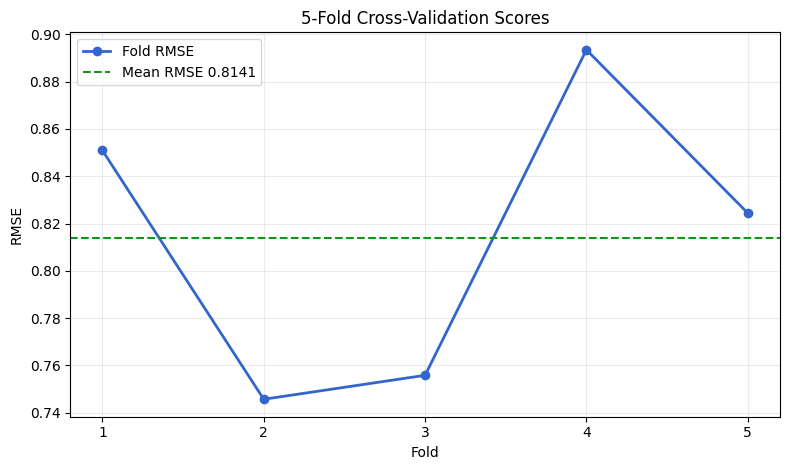

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
folds = np.arange(1, len(cv_rmse) + 1)
ax.plot(folds, cv_rmse, marker="o", linewidth=2, color="#3366cc", label="Fold RMSE")
ax.axhline(cv_rmse.mean(), color="#109618", linestyle="--", label=f"Mean RMSE {cv_rmse.mean():.4f}")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE")
ax.set_title("5-Fold Cross-Validation Scores")
ax.set_xticks(folds)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "cross_validation_scores.png", dpi=180)
plt.show()

## Hyperparameter Tuning

GridSearchCV systematically tests combinations of Decision Tree complexity controls. The grid tunes `max_depth` and `min_samples_split`, using five-fold cross-validation and negative RMSE as the scoring function.

In [11]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE: 0.6366408923917068


In [12]:
hyperparameter_results = pd.DataFrame(grid_search.cv_results_)[[
    "param_max_depth",
    "param_min_samples_split",
    "mean_train_score",
    "std_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()
hyperparameter_results["mean_train_rmse"] = -hyperparameter_results["mean_train_score"]
hyperparameter_results["mean_cv_rmse"] = -hyperparameter_results["mean_test_score"]
hyperparameter_results["std_cv_rmse"] = hyperparameter_results["std_test_score"]
hyperparameter_results = hyperparameter_results.sort_values("rank_test_score").reset_index(drop=True)
hyperparameter_results.to_csv(BASE_DIR / "hyperparameter_results.csv", index=False)
hyperparameter_results.head(10)

,param_max_depth,param_min_samples_split,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score,mean_train_rmse,mean_cv_rmse,std_cv_rmse
0,10,10,-0.463327,0.005471,-0.636641,0.007117,1,0.463327,0.636641,0.007117
1,10,5,-0.453764,0.005253,-0.637956,0.013152,2,0.453764,0.637956,0.013152
2,10,2,-0.449381,0.005318,-0.642493,0.008565,3,0.449381,0.642493,0.008565
3,7,2,-0.601039,0.008408,-0.652764,0.012875,4,0.601039,0.652764,0.012875
4,7,10,-0.602455,0.008217,-0.653486,0.013921,5,0.602455,0.653486,0.013921
5,7,5,-0.601282,0.008363,-0.653533,0.014236,6,0.601282,0.653533,0.014236
6,5,2,-0.691576,0.005030,-0.712696,0.014033,7,0.691576,0.712696,0.014033
7,5,5,-0.691576,0.005030,-0.712696,0.014033,7,0.691576,0.712696,0.014033
8,5,10,-0.691922,0.005276,-0.712722,0.013350,9,0.691922,0.712722,0.013350
9,3,5,-0.784806,0.002988,-0.795664,0.012193,10,0.784806,0.795664,0.012193


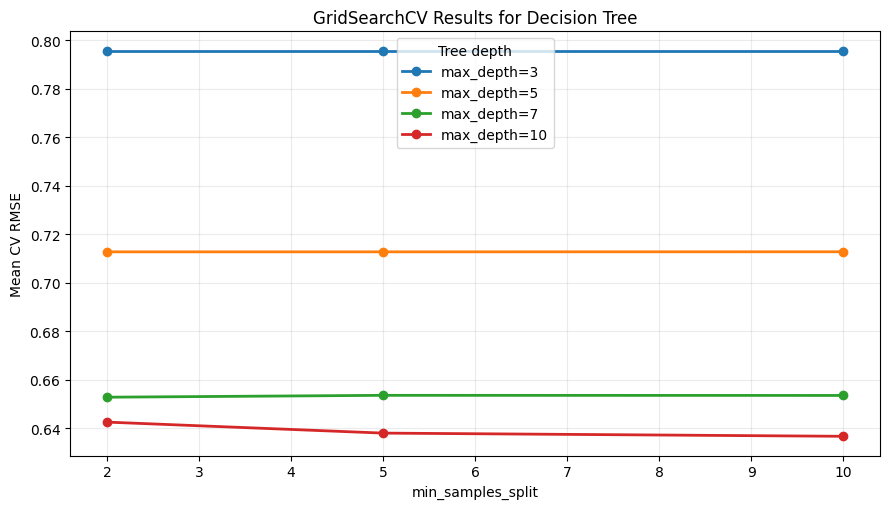

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.2))
for depth, group in hyperparameter_results.sort_values("param_min_samples_split").groupby("param_max_depth"):
    ax.plot(group["param_min_samples_split"].astype(int), group["mean_cv_rmse"],
            marker="o", linewidth=2, label=f"max_depth={depth}")
ax.set_xlabel("min_samples_split")
ax.set_ylabel("Mean CV RMSE")
ax.set_title("GridSearchCV Results for Decision Tree")
ax.grid(alpha=0.25)
ax.legend(title="Tree depth")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "grid_search_results.png", dpi=180)
plt.show()

## Optimized Model

The best estimator selected by GridSearchCV is retrained on the training set and evaluated on the held-out test set. This creates a direct comparison against the baseline models.

In [14]:
tuned_tree = grid_search.best_estimator_
tuned_tree.fit(X_train, y_train)
tuned_predictions = tuned_tree.predict(X_test)

tuned_row = {
    "Model": "Tuned Decision Tree",
    "RMSE": rmse(y_test, tuned_predictions),
    "R2 Score": float(r2_score(y_test, tuned_predictions)),
    "Model Type": "Optimized",
}
tuned_row

{'Model': 'Tuned Decision Tree',
 'RMSE': 0.6454300828015771,
 'R2 Score': 0.6820992539714815,
 'Model Type': 'Optimized'}

## Model Comparison

All models are ranked by highest R2 score and then lowest RMSE. This selection rule rewards explained variance while still prioritizing lower prediction error.

In [15]:
comparison_df = pd.DataFrame([*baseline_rows, tuned_row]).sort_values(
    by=["R2 Score", "RMSE"], ascending=[False, True]
).reset_index(drop=True)
comparison_df.insert(0, "Rank", np.arange(1, len(comparison_df) + 1))
comparison_df.to_csv(BASE_DIR / "model_comparison.csv", index=False)
comparison_df

,Rank,Model,RMSE,R2 Score,Model Type
0,1,Tuned Decision Tree,0.645430,0.682099,Optimized
1,2,Original Decision Tree,0.724234,0.599732,Baseline
2,3,Ridge Regression,0.745554,0.575819,Baseline
3,4,Linear Regression,0.745581,0.575788,Baseline


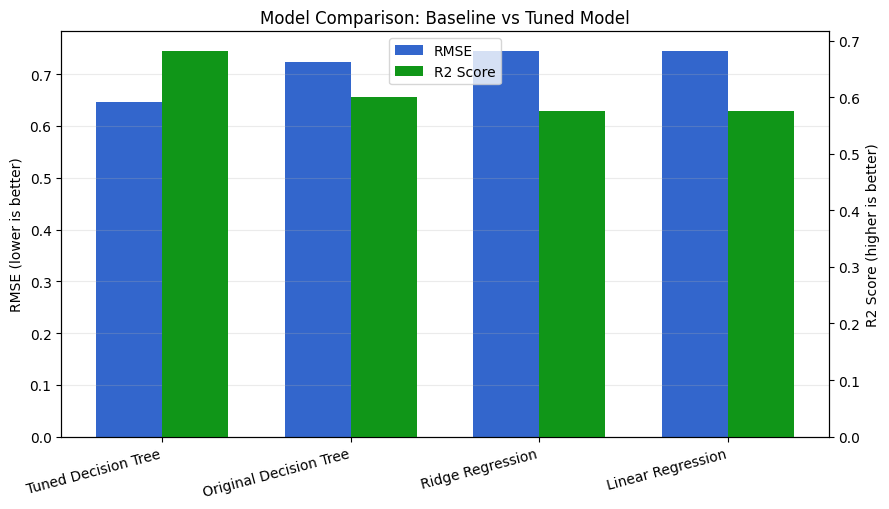

In [16]:
fig, ax1 = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x - width / 2, comparison_df["RMSE"], width, color="#3366cc", label="RMSE")
ax1.set_ylabel("RMSE (lower is better)")
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
ax1.grid(axis="y", alpha=0.25)
ax2 = ax1.twinx()
ax2.bar(x + width / 2, comparison_df["R2 Score"], width, color="#109618", label="R2 Score")
ax2.set_ylabel("R2 Score (higher is better)")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper center")
ax1.set_title("Model Comparison: Baseline vs Tuned Model")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "model_comparison.png", dpi=180)
plt.show()

## Best Model Selection

The selected model is the top-ranked entry in the comparison table. The final choice balances predictive accuracy, controlled complexity, and cross-validated tuning evidence. GridSearchCV reduces overfitting risk by selecting hyperparameters that perform well across validation folds rather than only on the training data.

In [17]:
best_model_name = comparison_df.loc[0, "Model"]
all_models = {**fitted_models, "Tuned Decision Tree": tuned_tree}
all_predictions = {**predictions_by_model, "Tuned Decision Tree": tuned_predictions}
best_model = all_models[best_model_name]
best_predictions = all_predictions[best_model_name]

print(f"Best model selected: {best_model_name}")
print(comparison_df.loc[0])

Best model selected: Tuned Decision Tree
Rank                            1
Model         Tuned Decision Tree
RMSE                      0.64543
R2 Score                 0.682099
Model Type              Optimized
Name: 0, dtype: object


## Saving Model

The selected model is saved with the fitted scaler, feature names, target name, selection rule, and best hyperparameters. Reloading the bundle verifies that it can be reused for predictions.

In [18]:
model_bundle = {
    "model_name": str(best_model_name),
    "model": best_model,
    "scaler": scaler,
    "feature_names": feature_names,
    "target_name": "HousePrice",
    "selection_rule": "Highest R2 Score, then lowest RMSE",
    "best_hyperparameters": grid_search.best_params_,
}
joblib.dump(model_bundle, BASE_DIR / "best_model.joblib")

loaded_bundle = joblib.load(BASE_DIR / "best_model.joblib")
loaded_predictions = loaded_bundle["model"].predict(X_test[:5])
print("Reloaded model prediction sample:", loaded_predictions)

Reloaded model prediction sample: [0.55230097 0.72655118 4.96858    2.25404688 2.04551471]


In [19]:
sample_predictions = pd.DataFrame({
    "Actual Values": y_test.reset_index(drop=True).iloc[:20].round(4),
    "Predicted Values": np.round(best_predictions[:20], 4),
})
sample_predictions.to_csv(BASE_DIR / "sample_predictions.csv", index=False)
sample_predictions

,Actual Values,Predicted Values
0,0.477,0.5523
1,0.458,0.7266
2,5.000,4.9686
3,2.186,2.2540
4,2.780,2.0455
5,1.587,1.4851
6,1.982,2.1761
7,1.575,1.6981
8,3.400,2.3426
9,4.466,4.9783


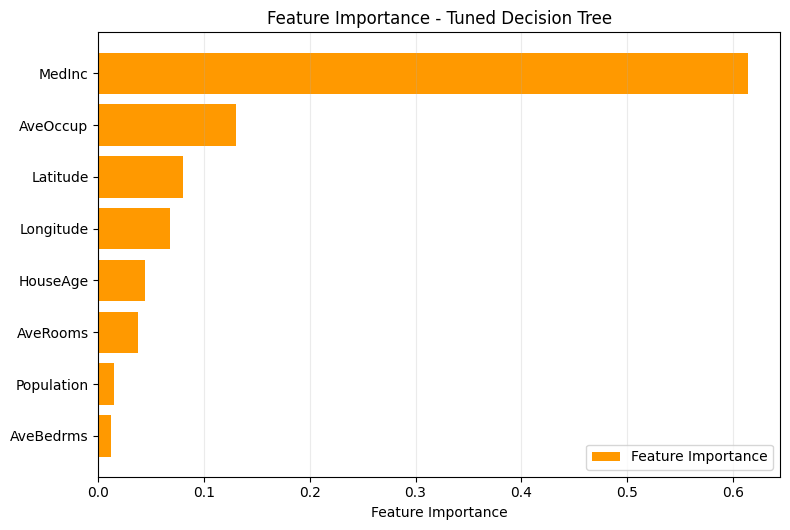

In [20]:
if hasattr(best_model, "feature_importances_"):
    importance_values = np.asarray(best_model.feature_importances_)
    importance_label = "Feature Importance"
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(np.asarray(best_model.coef_))
    importance_label = "Absolute Coefficient Magnitude"
else:
    importance_values = np.zeros(len(feature_names))
    importance_label = "Importance Proxy"

order = np.argsort(importance_values)
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.barh(np.asarray(feature_names)[order], importance_values[order], color="#ff9900", label=importance_label)
ax.set_xlabel(importance_label)
ax.set_title(f"Feature Importance - {best_model_name}")
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "feature_importance.png", dpi=180)
plt.show()

In [21]:
metrics = {
    "project_title": "Model Validation, Overfitting Control & Hyperparameter Tuning",
    "dataset": "California Housing dataset from sklearn.datasets.fetch_california_housing(as_frame=True)",
    "target_variable": "HousePrice",
    "features": feature_names,
    "row_count": int(df.shape[0]),
    "column_count": int(df.shape[1]),
    "missing_values": {column: int(value) for column, value in df.isna().sum().items()},
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "test_size_ratio": 0.20,
    "random_state": RANDOM_STATE,
    "scaler": "StandardScaler",
    "baseline_models": baseline_rows,
    "overfitting_analysis": {
        "model": "Original Decision Tree",
        "train_rmse": overfitting_analysis["Train RMSE"],
        "test_rmse": overfitting_analysis["Test RMSE"],
        "rmse_gap": overfitting_analysis["RMSE Gap"],
    },
    "cross_validation": {
        "model": "Original Decision Tree",
        "cv": 5,
        "fold_rmse": [float(x) for x in cv_rmse],
        "mean_rmse": float(cv_rmse.mean()),
        "std_rmse": float(cv_rmse.std()),
    },
    "grid_search": {
        "model": "DecisionTreeRegressor",
        "param_grid": param_grid,
        "cv": 5,
        "scoring": "neg_root_mean_squared_error",
        "best_params": grid_search.best_params_,
        "best_cv_rmse": float(-grid_search.best_score_),
    },
    "models": comparison_df.to_dict(orient="records"),
    "best_model": str(best_model_name),
    "best_model_metrics": comparison_df.loc[0].to_dict(),
    "selection_rule": "Highest R2 Score; if tied, lowest RMSE",
    "reloaded_model_prediction_sample": [float(x) for x in loaded_predictions],
}

with open(BASE_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics["best_model_metrics"], indent=2))

{
  "Rank": 1,
  "Model": "Tuned Decision Tree",
  "RMSE": 0.6454300828015771,
  "R2 Score": 0.6820992539714815,
  "Model Type": "Optimized"
}


## Conclusions

The tuned Decision Tree improves generalization compared with the original controlled tree by selecting depth and split thresholds through five-fold cross-validation. The workflow demonstrates overfitting detection, validation beyond a single split, hyperparameter tuning, objective model selection, and reproducible artifact generation.

## Future Improvements

Future work can include scikit-learn Pipelines to avoid any preprocessing leakage, nested cross-validation for more conservative model selection, residual diagnostics, and stronger ensemble models such as Random Forest or Gradient Boosting.